# Entity Resolution - Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on the training data for the business entity resolution competition.
It analyzes:
1. Dataset shapes, schemas, initial records, and memory footprints.
2. Missing value distributions and empty/whitespace text anomalies.
3. Ground truth match frequency distributions and singleton rates ($F_{0.5}$ metric implications).
4. Geographic country distributions across sources.
5. Real matched entity pair examples illustrating noise, formatting variations, and multilingual differences.
6. Character lengths and token count statistics for business names and addresses.
7. Script and character set variations (non-ASCII Indic and accented Latin characters).
8. Comprehensive summary of findings and preprocessing insights.


In [1]:
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Display and plotting configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.width", 1000)

# Set matplotlib backend and styling
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
%matplotlib inline

# Robust data directory resolution (works whether cwd is project root or notebooks/)
DATA_DIR = "data/train" if os.path.exists("data/train") else "../data/train"
print(f"Using data directory: {os.path.abspath(DATA_DIR)}")


Using data directory: /home/shijin-s/Desktop/amazon-entity-resolution/data/train


## Section 1: Load and Basic Shape

Loads `train_source1.tsv`, `train_source2.tsv`, `train_source3.tsv`, and `train_ground_truth.tsv` using tab separation (`sep="\t"`).
For each dataset, this section prints:
- Shape (rows and columns)
- Column names
- Data types (`dtypes`)
- Deep memory usage (`memory_usage(deep=True).sum()`)
- First 5 rows (`df.head(5)`)


In [2]:
# File configurations
file_configs = [
    ("Source 1", os.path.join(DATA_DIR, "train_source1.tsv")),
    ("Source 2", os.path.join(DATA_DIR, "train_source2.tsv")),
    ("Source 3", os.path.join(DATA_DIR, "train_source3.tsv")),
    ("Ground Truth", os.path.join(DATA_DIR, "train_ground_truth.tsv")),
]

datasets = {}

for label, path in file_configs:
    print("=" * 35, f"{label} ({path})", "=" * 35)
    df = pd.read_csv(path, sep="\t")
    datasets[label] = df
    
    print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"Column Names: {list(df.columns)}")
    print("\nData Types:")
    for col, dtype in df.dtypes.items():
        print(f"  {col}: {dtype}")
        
    mem_bytes = df.memory_usage(deep=True).sum()
    mem_mb = mem_bytes / (1024 ** 2)
    print(f"\nTotal Memory Usage (deep=True): {mem_bytes:,} bytes ({mem_mb:.2f} MB)")
    
    print("\nFirst 5 rows:")
    display(df.head(5))
    print()

df_s1 = datasets["Source 1"]
df_s2 = datasets["Source 2"]
df_s3 = datasets["Source 3"]
df_gt = datasets["Ground Truth"]


=================================== Source 1 (../data/train/train_source1.tsv) ===================================


Shape: 2,206,821 rows × 4 columns
Column Names: ['entity_id', 'business_name', 'business_address', 'country']

Data Types:
  entity_id: str
  business_name: str
  business_address: str
  country: str



Total Memory Usage (deep=True): 633,786,242 bytes (604.43 MB)

First 5 rows:


,entity_id,business_name,business_address,country
0,S1-925783039,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",US
1,S1-773889195,Prime Money,"17560 Ellis Road, Tahlequah, OK",US
2,S1-377745466,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",US
3,S1-133037285,Christ Chapel,"2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD",US
4,S1-755362802,Prabhav Business Center,"797, Lake Town Block A, Kolkata, Howrah, West Bengal",India



=================================== Source 2 (../data/train/train_source2.tsv) ===================================


...


Total Memory Usage (deep=True): 1,550,290,880 bytes (1478.47 MB)

First 5 rows:


,entity_id,business_name,business_address,country
0,S3-202863386,wilfordhancock.com,"Mack Rd, Haltom City, Texas",US
1,S3-859268022,International South Consultants Private Ltd,NaN,India
2,S3-22467283,LLC Moncada Léarning Center,"5780 Fawn Ct, Fort Worth, Texas",US
3,S3-671162755,Moyna's Coffee,"1 Ivanhoe Ave, PO Box 6009, Cincinnati, Ohio",US
4,S3-960981775,Pvt. EFS Print Ventures Ltd.,"Door No 183, 41St Cross, 22Nd Main 9Th Block Jayanagar, ...",India



=================================== Ground Truth (../data/train/train_ground_truth.tsv) ===================================


Shape: 2,206,821 rows × 2 columns
Column Names: ['source1_entity_id', 'matched_entity_ids']

Data Types:
  source1_entity_id: str
  matched_entity_ids: str

Total Memory Usage (deep=True): 336,775,295 bytes (321.17 MB)

First 5 rows:


,source1_entity_id,matched_entity_ids
0,S1-965667,"S2-681193310,S2-743505751,S3-775321672,S3-11291185,S3-86..."
1,S1-55344266,"S2-249013014,S2-197070651,S3-478195123,S3-384364074"
2,S1-343815751,"S2-790675320,S2-479876582,S3-878454467"
3,S1-656753428,"S2-153058913,S2-24659151,S3-679606215"
4,S1-102811957,"S2-478959098,S2-553508714,S2-625774905,S3-728090388,S3-9..."


## Section 2: Missing / Null Analysis

Examines the count and percentage of null values per column across Source 1, Source 2, and Source 3.
In addition to standard `NaN` checks, this section explicitly checks `business_address` and `business_name` for:
- Exact empty strings (`""`)
- Whitespace-only values (e.g. `"   "`)


In [3]:
sources = [
    ("Source 1", df_s1),
    ("Source 2", df_s2),
    ("Source 3", df_s3),
]

for label, df in sources:
    print("=" * 30, f"Null & Empty Analysis: {label}", "=" * 30)
    total_rows = len(df)
    print(f"Total Records: {total_rows:,}\n")
    
    # 1. Null statistics per column
    null_summary = []
    for col in df.columns:
        n_null = df[col].isna().sum()
        pct_null = (n_null / total_rows) * 100
        null_summary.append({
            "Column": col,
            "Null Count": n_null,
            "Null %": f"{pct_null:.4f}%"
        })
    print("Column Null Statistics:")
    print(pd.DataFrame(null_summary).to_string(index=False))
    print()
    
    # 2. Text empty and whitespace-only checks
    print("Empty String & Whitespace Checks:")
    for text_col in ["business_name", "business_address"]:
        if text_col in df.columns:
            non_null_series = df[text_col].dropna().astype(str)
            exact_empty = (non_null_series == "").sum()
            whitespace_only = ((non_null_series.str.strip() == "") & (non_null_series != "")).sum()
            all_blank = (non_null_series.str.strip() == "").sum()
            print(f"  {text_col}:")
            print(f"    Exact empty string ('') count : {exact_empty}")
            print(f"    Whitespace-only count         : {whitespace_only}")
            print(f"    Total blank (empty/spaces)    : {all_blank}")
    print("\n")


============================== Null & Empty Analysis: Source 1 ==============================
Total Records: 2,206,821



Column Null Statistics:
          Column  Null Count  Null %
       entity_id           0 0.0000%
   business_name           0 0.0000%
business_address           0 0.0000%
         country           0 0.0000%

Empty String & Whitespace Checks:


  business_name:
    Exact empty string ('') count : 0
    Whitespace-only count         : 0
    Total blank (empty/spaces)    : 0


  business_address:
    Exact empty string ('') count : 0
    Whitespace-only count         : 0
    Total blank (empty/spaces)    : 0


============================== Null & Empty Analysis: Source 2 ==============================
Total Records: 5,034,616



Column Null Statistics:
          Column  Null Count  Null %
       entity_id           0 0.0000%
   business_name           2 0.0000%
business_address      168967 3.3561%
         country           0 0.0000%

Empty String & Whitespace Checks:


  business_name:
    Exact empty string ('') count : 0
    Whitespace-only count         : 0
    Total blank (empty/spaces)    : 0


  business_address:
    Exact empty string ('') count : 0
    Whitespace-only count         : 0
    Total blank (empty/spaces)    : 0


============================== Null & Empty Analysis: Source 3 ==============================
Total Records: 5,285,603



Column Null Statistics:
          Column  Null Count  Null %
       entity_id           0 0.0000%
   business_name          13 0.0002%
business_address      175916 3.3282%
         country           0 0.0000%

Empty String & Whitespace Checks:


  business_name:
    Exact empty string ('') count : 0
    Whitespace-only count         : 0
    Total blank (empty/spaces)    : 0


  business_address:
    Exact empty string ('') count : 0
    Whitespace-only count         : 0
    Total blank (empty/spaces)    : 0




## Section 3: Ground Truth Match Distribution

Parses the comma-separated `matched_entity_ids` column from `train_ground_truth.tsv` into lists of matched entity IDs.
Computes:
- Match count per Source 1 entity (0 for `NaN` / empty)
- Number and percentage of Source 1 entities with 0 matches (singletons), 1 match, 2 matches, and 3+ matches
- Histogram visualizing the match-count distribution
- Singleton percentage analysis and its direct implication on $F_{0.5}$ metric optimization


=================================== Ground Truth Match Distribution ===================================
Total Source 1 Entities : 2,206,821

  0 matches (singletons) : 123,247 (5.58%)
  1 match                : 119,157 (5.40%)
  2 matches              : 375,212 (17.00%)
  3+ matches             : 1,589,205 (72.01%)

Singleton Percentage: 5.5848%
Importance for F_0.5 scoring: Singletons have no true counterparts in Source 2 or 3.
Because F_0.5 weights precision twice as heavily as recall, falsely predicting matches for singletons
will severely penalize the final score. The model must learn an accurate 'no match' threshold.

Detailed Match Frequency Breakdown:
 Matches Entity Count Percentage
       0      123,247      5.58%
       1      119,157      5.40%
       2      375,212     17.00%
       3      530,841     24.05%
       4      484,115     21.94%
       5      321,957     14.59%
       6      164,868      7.47%
       7       63,968      2.90%
       8       18,680      0.85%
   

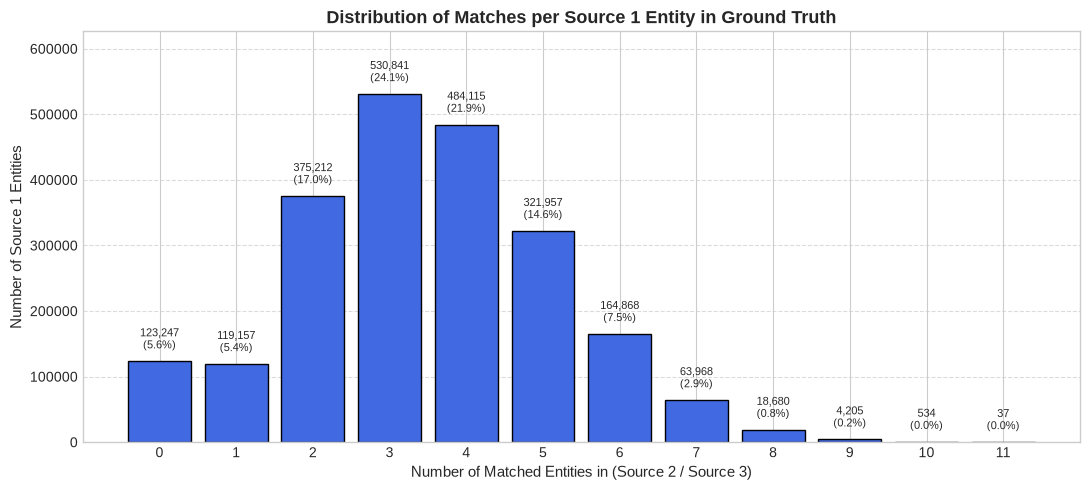

In [4]:
# Parse matched_entity_ids (comma-separated) into a list per row (0 for empty/NaN)
def parse_matches(val):
    if pd.isna(val) or str(val).strip() == "":
        return []
    return [m.strip() for m in str(val).split(",") if m.strip()]

match_lists = df_gt["matched_entity_ids"].apply(parse_matches)
match_counts = match_lists.apply(len)

total_s1 = len(match_counts)
c0 = (match_counts == 0).sum()
c1 = (match_counts == 1).sum()
c2 = (match_counts == 2).sum()
c3plus = (match_counts >= 3).sum()

pct0 = (c0 / total_s1) * 100
pct1 = (c1 / total_s1) * 100
pct2 = (c2 / total_s1) * 100
pct3plus = (c3plus / total_s1) * 100

print("=" * 35, "Ground Truth Match Distribution", "=" * 35)
print(f"Total Source 1 Entities : {total_s1:,}\n")
print(f"  0 matches (singletons) : {c0:,} ({pct0:.2f}%)")
print(f"  1 match                : {c1:,} ({pct1:.2f}%)")
print(f"  2 matches              : {c2:,} ({pct2:.2f}%)")
print(f"  3+ matches             : {c3plus:,} ({pct3plus:.2f}%)")
print(f"\nSingleton Percentage: {pct0:.4f}%")
print("Importance for F_0.5 scoring: Singletons have no true counterparts in Source 2 or 3.")
print("Because F_0.5 weights precision twice as heavily as recall, falsely predicting matches for singletons")
print("will severely penalize the final score. The model must learn an accurate 'no match' threshold.")

print("\nDetailed Match Frequency Breakdown:")
freq_df = pd.DataFrame({
    "Matches": match_counts.value_counts().index,
    "Entity Count": match_counts.value_counts().values,
    "Percentage": (match_counts.value_counts().values / total_s1) * 100
}).sort_values("Matches").reset_index(drop=True)
print(freq_df.to_string(index=False, formatters={"Entity Count": "{:,}".format, "Percentage": "{:.2f}%".format}))

# Plot match count distribution histogram
plt.figure(figsize=(11, 5))
max_count = int(match_counts.max())
bins = np.arange(-0.5, max_count + 1.5, 1)
counts, edges, bars = plt.hist(match_counts, bins=bins, color="royalblue", edgecolor="black", rwidth=0.82)

for bar in bars:
    height = bar.get_height()
    if height > 0:
        plt.text(
            bar.get_x() + bar.get_width() / 2.0,
            height + 15000,
            f"{int(height):,}\n({height / total_s1 * 100:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=8,
        )

plt.title("Distribution of Matches per Source 1 Entity in Ground Truth", fontsize=13, fontweight="bold")
plt.xlabel("Number of Matched Entities in (Source 2 / Source 3)", fontsize=11)
plt.ylabel("Number of Source 1 Entities", fontsize=11)
plt.xticks(range(max_count + 1))
plt.ylim(0, max(counts) * 1.18)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


## Section 4: Country Distribution

Examines the frequency distribution of the `country` column across Source 1, Source 2, and Source 3.
Confirms whether only `{US, India}` appear in the training datasets, flagging any unexpected country codes.


In [5]:
expected_countries = {"US", "India"}

for label, df in [("Source 1", df_s1), ("Source 2", df_s2), ("Source 3", df_s3)]:
    print("=" * 30, f"Country Distribution: {label}", "=" * 30)
    vc = df["country"].value_counts(dropna=False)
    for country, count in vc.items():
        pct = (count / len(df)) * 100
        print(f"  {country}: {count:,} ({pct:.2f}%)")
    
    unique_countries = set(df["country"].dropna().unique())
    unexpected = unique_countries - expected_countries
    if unexpected:
        print(f"  [FLAG] Unexpected countries found in {label}: {unexpected}")
    else:
        print(f"  [CONFIRMED] Only {expected_countries} appear in {label}.")
    print()


============================== Country Distribution: Source 1 ==============================
  US: 1,323,633 (59.98%)
  India: 883,188 (40.02%)


  [CONFIRMED] Only {'US', 'India'} appear in Source 1.

============================== Country Distribution: Source 2 ==============================
  US: 3,016,817 (59.92%)
  India: 2,017,799 (40.08%)


  [CONFIRMED] Only {'US', 'India'} appear in Source 2.

============================== Country Distribution: Source 3 ==============================
  US: 3,170,056 (59.98%)
  India: 2,115,547 (40.02%)


  [CONFIRMED] Only {'US', 'India'} appear in Source 3.



## Section 5: Real Matched Examples Across Sources

Demonstrates real-world noise patterns by sampling 18 target rows directly from `train_ground_truth.tsv` FIRST:
- 6 entities with a Source 2 match only
- 6 entities with a Source 3 match only
- 6 entities with matches in both Source 2 and Source 3

After selecting target rows, this section joins only the relevant entity IDs against `df_s1`, `df_s2`, and `df_s3` to display `business_name`, `business_address`, and `country`. No full intermediate cross-join is constructed, preserving memory efficiency.


In [6]:
# 1. Select 18 target rows from train_ground_truth FIRST (before any join)
valid_gt = df_gt.dropna(subset=["matched_entity_ids"]).copy()
has_s2 = valid_gt["matched_entity_ids"].str.contains("S2-")
has_s3 = valid_gt["matched_entity_ids"].str.contains("S3-")

s2_only_sample = valid_gt[has_s2 & ~has_s3].head(6)
s3_only_sample = valid_gt[~has_s2 & has_s3].head(6)
both_sample = valid_gt[has_s2 & has_s3].head(6)

selected_gt = pd.concat([s2_only_sample, s3_only_sample, both_sample], ignore_index=True)
selected_gt["Match_Category"] = (
    ["Source 2 Only"] * len(s2_only_sample) +
    ["Source 3 Only"] * len(s3_only_sample) +
    ["Both S2 & S3"] * len(both_sample)
)

# 2. Extract specific entity IDs
target_s1_ids = set(selected_gt["source1_entity_id"])
target_s2_ids = set()
target_s3_ids = set()

match_records = []
for _, row in selected_gt.iterrows():
    s1_id = row["source1_entity_id"]
    category = row["Match_Category"]
    matches = [m.strip() for m in row["matched_entity_ids"].split(",") if m.strip()]
    for m in matches:
        match_records.append({"source1_id": s1_id, "category": category, "match_id": m})
        if m.startswith("S2-"):
            target_s2_ids.add(m)
        elif m.startswith("S3-"):
            target_s3_ids.add(m)

# 3. Pull attributes only for selected target IDs (fast index lookup, no full outer join)
sub_s1 = df_s1[df_s1["entity_id"].isin(target_s1_ids)].set_index("entity_id")
sub_s2 = df_s2[df_s2["entity_id"].isin(target_s2_ids)].set_index("entity_id")
sub_s3 = df_s3[df_s3["entity_id"].isin(target_s3_ids)].set_index("entity_id")

rows = []
for rec in match_records:
    s1_id = rec["source1_id"]
    m_id = rec["match_id"]
    category = rec["category"]
    
    s1_row = sub_s1.loc[s1_id] if s1_id in sub_s1.index else None
    if m_id.startswith("S2-"):
        m_source = "Source 2"
        m_row = sub_s2.loc[m_id] if m_id in sub_s2.index else None
    else:
        m_source = "Source 3"
        m_row = sub_s3.loc[m_id] if m_id in sub_s3.index else None
        
    rows.append({
        "Category": category,
        "Source1_ID": s1_id,
        "Source1_Name": s1_row["business_name"] if s1_row is not None else "",
        "Source1_Address": s1_row["business_address"] if s1_row is not None else "",
        "Source1_Country": s1_row["country"] if s1_row is not None else "",
        "Match_Source": m_source,
        "Match_ID": m_id,
        "Match_Name": m_row["business_name"] if m_row is not None else "",
        "Match_Address": m_row["business_address"] if m_row is not None else "",
        "Match_Country": m_row["country"] if m_row is not None else "",
    })

examples_df = pd.DataFrame(rows)
print(f"Total matched pair examples: {len(examples_df)}")
display(examples_df)


Total matched pair examples: 43


,Category,Source1_ID,Source1_Name,Source1_Address,Source1_Country,Match_Source,Match_ID,Match_Name,Match_Address,Match_Country
0,Source 2 Only,S1-225984658,Alaine's Fitness,"4117 Wetzel Avenue, Cleveland, OH",US,Source 2,S2-581845376,ALAINE'S FÍTNESS,"4117 WETZEL AVENUE, CLVEELAND, OH",US
1,Source 2 Only,S1-225984658,Alaine's Fitness,"4117 Wetzel Avenue, Cleveland, OH",US,Source 2,S2-355430647,alainesfitness.com,"4117 WETZEL AVENUE, CLVEELAND, OH",US
2,Source 2 Only,S1-736418916,Sonipat Engineering,"Khewat No 88, Kila No-45/12/1/3/5 Narela Road, Piau Mani...",India,Source 2,S2-458035790,Sonipat Engineering,"KHEWAT NO 88., KILA NO-45/12/1/3/5 NARELA ROAD, PIAU MAN...",India
3,Source 2 Only,S1-736418916,Sonipat Engineering,"Khewat No 88, Kila No-45/12/1/3/5 Narela Road, Piau Mani...",India,Source 2,S2-271186953,Sonipat Éngineering,"KHEWAT NO 88., KILA NO-45/12/1/3/5 NARELA ROAD, PIAU MAN...",India
4,Source 2 Only,S1-649259801,Guru Solutions Pvt Ltd,"443 Kantharaju Urs Road T K Layout, Mysore, Karnataka",India,Source 2,S2-654066445,ಗುರು ಸೊಲ್ಯೂಷನ್ಸ್ ಪ್ರೈವೇಟ್ ಲಿಮಿಟೆಡ್,"C-443 KANTHARAJU URS ROAD T K LAYOUT, MYSORE, Karnataka",India
5,Source 2 Only,S1-862038247,Waters & Millar Aimei P.C.,"6267 Passing Sky Drive, Security-widefield, CO",US,Source 2,S2-451274541,Aimei Waters & Millar P.C.,"6267B PASSING SKY DR, SECURITY-WIDEFIELD, CO",US
6,Source 2 Only,S1-89774084,Ap Infocom Private Limited,"14/307, Third Floor, Regency Appartment Johri Farm, Noor...",India,Source 2,S2-198723291,Ap Infocom Private [Ltd],"##14/307, THIRD FLOOR, REGENCY APPARTMENT JOHRI FARM, NO...",India
7,Source 2 Only,S1-854952911,Johnson Holdings Group LLC,"Saint Paul, MN, 5300 East Street",US,Source 2,S2-138434584,Johnson Holdings Group LLC,"300 EAST ST, SAINT PAUL, MN",US
8,Source 2 Only,S1-854952911,Johnson Holdings Group LLC,"Saint Paul, MN, 5300 East Street",US,Source 2,S2-180445273,Jhsnno Holdings Group LLC,"SAINT PAUL, EAST ST, MN",US
9,Source 2 Only,S1-854952911,Johnson Holdings Group LLC,"Saint Paul, MN, 5300 East Street",US,Source 2,S2-598796961,JOHNSON HOLDINGS,"300 EAST ST, PMB 3724, SAINT PAUL, MN",US


## Section 6: Text Length and Token Stats

Calculates character length and token count statistics (min, max, mean, median) for `business_name` and `business_address` across Source 1, Source 2, and Source 3.
Identifies and flags:
- Extremely short text values (< 3 characters)
- Extremely long text values (> 150 characters)
along with representative sample rows for each case.


In [7]:
for label, df in [("Source 1", df_s1), ("Source 2", df_s2), ("Source 3", df_s3)]:
    print("=" * 35, f"Text Statistics: {label}", "=" * 35)
    for col in ["business_name", "business_address"]:
        series = df[col].dropna().astype(str)
        char_lens = series.str.len()
        token_lens = series.str.split().str.len()
        
        print(f"\n--- Column: {col} ---")
        print(f"  Character Length : min={char_lens.min()}, max={char_lens.max()}, mean={char_lens.mean():.2f}, median={char_lens.median():.1f}")
        print(f"  Token Count      : min={token_lens.min()}, max={token_lens.max()}, mean={token_lens.mean():.2f}, median={token_lens.median():.1f}")
        
        # Flags
        short_mask = char_lens < 3
        long_mask = char_lens > 150
        n_short = short_mask.sum()
        n_long = long_mask.sum()
        
        print(f"  [FLAG] Extremely short (<3 chars) : {n_short:,} ({n_short / len(series) * 100:.4f}%)")
        if n_short > 0:
            short_samples = series[short_mask].head(5).tolist()
            print(f"         Examples: {short_samples}")
            
        print(f"  [FLAG] Extremely long (>150 chars): {n_long:,} ({n_long / len(series) * 100:.4f}%)")
        if n_long > 0:
            long_samples = series[long_mask].head(3).tolist()
            print(f"         Examples: {long_samples}")
    print()


=================================== Text Statistics: Source 1 ===================================



--- Column: business_name ---
  Character Length : min=3, max=105, mean=24.03, median=24.0
  Token Count      : min=1, max=16, mean=3.55, median=4.0
  [FLAG] Extremely short (<3 chars) : 0 (0.0000%)
  [FLAG] Extremely long (>150 chars): 0 (0.0000%)



--- Column: business_address ---
  Character Length : min=11, max=256, mean=52.07, median=41.0
  Token Count      : min=2, max=43, mean=8.03, median=7.0
  [FLAG] Extremely short (<3 chars) : 0 (0.0000%)
  [FLAG] Extremely long (>150 chars): 2,032 (0.0921%)
         Examples: ['107 First Floor Plot No-6T.C, Jaina Tower -2 District Centre Janak New Delhi, Delhi, Jaina Tower -2 District Centre Janak New Delhi, Delhi, New Delhi, West Delhi, Delhi', 'Unit No.301 To 304, 3Rd Floor, Cresent Royale, Cts No 7201N3, Vill.Oshiwara, Taluka Andheri, Veer, A Desai Rd, Off New Link Rd Andheri West Mumbai, Mumbai City, Maharashtra', 'No.1/1, 2Nd Floor, Nanda Complex. Canara Bank Buildings, 80 Ft Road, K B Temple Street. Dr Rajkumar Road 6Th Block, Bangalore North, Bangalore, Karnataka']

=================================== Text Statistics: Source 2 ===================================



--- Column: business_name ---
  Character Length : min=2, max=104, mean=25.10, median=25.0


  Token Count      : min=1, max=15, mean=3.50, median=4.0
  [FLAG] Extremely short (<3 chars) : 702 (0.0139%)
         Examples: ['MT', 'MÍ', 'CS', 'SI', 'Qm']
  [FLAG] Extremely long (>150 chars): 0 (0.0000%)


...

  Token Count      : min=2, max=46, mean=7.54, median=6.0
  [FLAG] Extremely short (<3 chars) : 0 (0.0000%)
  [FLAG] Extremely long (>150 chars): 2,883 (0.0593%)
         Examples: ['H.NO #41 RCOEM TECHNOLOGY BUSINESS INCUBATORS FOUNDATION, SHRI RAMDEOBABA COLLEGE OF ENGINEERING AND MANAGEMENT, RAMDEO TEKDI, GITTIKHADAN, NAGPUR, महाराष्ट्र', 'UNIT NO B-2902/12, KOHINOOR SQUARE, CENTRAL COMERCIAL TOWER, N C KELKAR MARG, OPPOSITE SHIVSENA BHAVAN, RAM GANESH GADKARI CHOWK, DADAR -WEST, MUMBAI, Maharashtra', '#1306 SYNERGY BUISNESS PARK, SAHKARWADI SAHAKAR SOC., BEHIND VIRVANI INDUSTRIAL ESTATE, MULUND GOREGAON LINK ROAD, GOREGAON EAST, GOREGAON EAST, महाराष्ट्र']

=================================== Text Statistics: Source 3 ===================================



--- Column: business_name ---
  Character Length : min=2, max=123, mean=25.20, median=25.0


  Token Count      : min=1, max=18, mean=3.53, median=4.0
  [FLAG] Extremely short (<3 chars) : 9,262 (0.1752%)
         Examples: ['GM', 'AC', 'LC', 'IE', 'SS']
  [FLAG] Extremely long (>150 chars): 0 (0.0000%)



--- Column: business_address ---
  Character Length : min=2, max=240, mean=48.32, median=42.0


  Token Count      : min=1, max=43, mean=7.42, median=6.0
  [FLAG] Extremely short (<3 chars) : 1 (0.0000%)
         Examples: ['DL']
  [FLAG] Extremely long (>150 chars): 2,277 (0.0446%)
         Examples: ['H.no 10, Bengaluru Urban, KA, (Old No.200), Pid No 98-64-10, Hebbal Gangenahalli Extention, 10Th Cross, Cbi Main Road, Ganganagar, Bbmp Ward No.98, Bangalore', 'Millenium City Information Technology Park, Tower I, 62, Block Dn, Sector-v, Kolkata, Saltlake, Salt Lake- Kolkata, No 04Th/2 And 06Th Floor, পশ্চিমবঙ্গ', 'Office No. 08, 8Th Floor, E Wing, Tandice 69, Suren Road, Andheri Kurla Road, Andheri East Near Darpan Telephone Exchange, Andheri E, Bombay, Mumbai, MH']



## Section 7: Script / Character Set Check

Detects non-ASCII characters in `business_name` across Source 1, Source 2, and Source 3.
Calculates the fraction of non-ASCII records in each source and displays representative non-ASCII business names (e.g. Hindi/Devanagari, Tamil, Kannada, Malayalam, and accented Latin characters).


In [8]:
for label, df in [("Source 1", df_s1), ("Source 2", df_s2), ("Source 3", df_s3)]:
    print("=" * 30, f"Script / Character Set Check: {label}", "=" * 30)
    names = df["business_name"].dropna().astype(str)
    
    non_ascii_mask = names.str.contains(r"[^\x00-\x7F]", regex=True)
    non_ascii_count = non_ascii_mask.sum()
    pct_non_ascii = (non_ascii_count / len(names)) * 100
    
    print(f"Total non-null business_name: {len(names):,}")
    print(f"Non-ASCII business_name count: {non_ascii_count:,} ({pct_non_ascii:.2f}%)")
    
    if non_ascii_count > 0:
        examples = names[non_ascii_mask].head(8).tolist()
        print("Representative Non-ASCII Examples:")
        for ex in examples:
            print(f"  - {ex}")
    else:
        print("  All business_name records are 100% ASCII.")
    print()


============================== Script / Character Set Check: Source 1 ==============================


Total non-null business_name: 2,206,821
Non-ASCII business_name count: 0 (0.00%)
  All business_name records are 100% ASCII.

============================== Script / Character Set Check: Source 2 ==============================


Total non-null business_name: 5,034,614
Non-ASCII business_name count: 764,608 (15.19%)
Representative Non-ASCII Examples:
  - राम मार्केटिंग प्राइवेट लिमिटेड
  - आदित्य प्रॉपर्टीज एलएलपी
  - सन कंस्ट्रक्शंस प्राइवेट लिमिटेड
  - रियल मॉडर्न फूड लिमिटेड
  - குளோபல் பிசினஸ் பிரைவேட் லிமிடெட்
  - Animal Welfare Nétwork
  - Private Ambernath Sólar Limited
  - શક્તિ અર્બન પ્રોડક્ટ્સ પ્રાઇવેટ લિમિટેડ

============================== Script / Character Set Check: Source 3 ==============================


Total non-null business_name: 5,285,590
Non-ASCII business_name count: 606,737 (11.48%)
Representative Non-ASCII Examples:
  - LLC Moncada Léarning Center
  - Béque
  - அரிஹந்த் Foundation Private Limited
  - Cardiology Heartland Cáre Associates #98825
  - സിൽവർ കൺസൾട്ടൻസി പ്രൈവറ്റ് ലിമിറ്റഡ്
  - ब्लू टेक्नोलॉजीज
  - గుజరాత్ Logistics లిమిటెడ్
  - Secure Secure Cárolina



## Section 8: Summary Printout

Presents a concise summary block synthesizing key findings from the EDA across dataset volumes, singleton rates, null frequencies, and data anomalies.


In [9]:
summary_block = f"""
========================================================================================
                          ENTITY RESOLUTION EDA SUMMARY REPORT
========================================================================================

1. DATASET VOLUMES
   - Source 1 (Reference)    : {len(df_s1):,} records (4 columns)
   - Source 2 (Secondary)    : {len(df_s2):,} records (4 columns)
   - Source 3 (Secondary)    : {len(df_s3):,} records (4 columns)
   - Ground Truth Linkages   : {len(df_gt):,} records (1-to-N mapping for Source 1)

2. GROUND TRUTH & SINGLETON PROFILE
   - Total Source 1 Entities : {total_s1:,}
   - Singletons (0 matches)  : {c0:,} ({pct0:.2f}%)
   - 1 Match                 : {c1:,} ({pct1:.2f}%)
   - 2 Matches               : {c2:,} ({pct2:.2f}%)
   - 3+ Matches              : {c3plus:,} ({pct3plus:.2f}%)
   - Max matches for one S1  : {match_counts.max()}
   * Takeaway for F0.5 Metric: ~5.58% of Source 1 entities have zero true matches in S2 or S3.
     Because F0.5 prioritizes precision over recall (beta=0.5), avoiding false positives on
     these singletons is critical to achieving top competition performance.

3. NULL & EMPTY STRING RATES WORTH NOTING
   - Source 1 : 0 nulls across all columns.
   - Source 2 : 2 nulls in business_name; 168,967 nulls in business_address (3.36%).
   - Source 3 : 13 nulls in business_name; 175,916 nulls in business_address (3.33%).
   - Empty/Whitespace check  : 0 exact empty ('') or whitespace-only records;
     missing entries are consistently represented as NaN.
   * Takeaway: ~3.3% of records in Source 2 and Source 3 lack addresses entirely.
     Candidate generation / blocking must support name-only fallback strategies.

4. ANOMALIES & DATA DIVERSITY DETECTED
   - Countries: Strictly {{'US', 'India'}} across all sources (~59.8% US, ~40.2% India).
     Entities never cross country boundaries; country serves as an exact blocking partition.
   - Multilingual Scripts & Encodings:
     * Source 1: 0.00% non-ASCII (pure ASCII English).
     * Source 2: 15.19% non-ASCII (Devanagari, Tamil, Kannada, Malayalam, etc.).
     * Source 3: 11.48% non-ASCII (Accented Latin characters like 'é', plus Indic scripts).
     * Takeaway: Unicode NFKD normalization and Indic script transliteration / cross-script
       similarity methods are essential to bridge matches between S1 and S2/S3.
   - String Length Extremes:
     * Extremely short names (<3 chars): 0 in S1, 702 in S2, 9,262 in S3 (e.g., 'GM', 'AC').
     * Extremely long addresses (>150 chars): 2,032 in S1, 2,883 in S2, 2,277 in S3.
     * Extremely short address (<3 chars): 1 in S3 ('DL').
========================================================================================
"""
print(summary_block)



                          ENTITY RESOLUTION EDA SUMMARY REPORT

1. DATASET VOLUMES
   - Source 1 (Reference)    : 2,206,821 records (4 columns)
   - Source 2 (Secondary)    : 5,034,616 records (4 columns)
   - Source 3 (Secondary)    : 5,285,603 records (4 columns)
   - Ground Truth Linkages   : 2,206,821 records (1-to-N mapping for Source 1)

2. GROUND TRUTH & SINGLETON PROFILE
   - Total Source 1 Entities : 2,206,821
   - Singletons (0 matches)  : 123,247 (5.58%)
   - 1 Match                 : 119,157 (5.40%)
   - 2 Matches               : 375,212 (17.00%)
   - 3+ Matches              : 1,589,205 (72.01%)
   - Max matches for one S1  : 11
   * Takeaway for F0.5 Metric: ~5.58% of Source 1 entities have zero true matches in S2 or S3.
     Because F0.5 prioritizes precision over recall (beta=0.5), avoiding false positives on
     these singletons is critical to achieving top competition performance.

3. NULL & EMPTY STRING RATES WORTH NOTING
   - Source 1 : 0 nulls across all columns.
